# Fill a waveguide with lossy material

In this tutorial we fill the rectangular waveguide with a dielectric
($\varepsilon_r = 2.25$), watch its cutoff frequency drop from 1.5 to 1.0 GHz,
then make the dielectric lossy ($\tan\delta = 0.005$) and measure how much
power it absorbs. Both cases are checked against the exact solution.

**Prerequisites:** the [Basics](../basics/index.md) tutorials.

## 1. Build a filled waveguide

### 1.1 Create the waveguide

This time we create the waveguide object ourselves, so that we can give it a
material before adding it to the project. The mesh is finer than in the
basics tutorials because the wavelength in the dielectric is shorter.

In [1]:
from cavsim3d.core.em_project import EMProject
from cavsim3d.geometry.primitives import RectangularWaveguide

proj = EMProject(name="materials_and_losses", base_dir="./simulations", overwrite=True)

guide = RectangularWaveguide(a=0.1, b=0.05, L=0.2, maxh=0.015)

✅ Creating new project 'materials_and_losses' at simulations\materials_and_losses


### 1.2 Assign the material

`set_materials` maps material names to properties. `'*'` matches every
material of the part.

In [2]:
guide.set_materials({"*": {"eps_r": 2.25}})
print(guide.get_material("vacuum"))

{'eps_r': 2.25, 'mu_r': 1.0, 'sigma': 0.0, 'tan_delta': 0.0}


The waveguide's single material is called `vacuum` in its mesh; the name does
not matter, the properties do: $\varepsilon_r = 2.25$, no loss.

### 1.3 Add it to the project

In [3]:
proj.add("guide", guide)
proj.parts

{'guide': <cavsim3d.geometry.primitives.RectangularWaveguide at 0x1779f5b5f50>}

### 1.4 Look at the material map

`draw_material_cf("eps")` colours the model by its relative permittivity.

In [4]:
proj.draw_material_cf("eps")


Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 1257


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

The whole guide shows the same colour: $\varepsilon_r = 2.25$ everywhere.

## 2. The lossless filling

### 2.1 Run the sweep

In [5]:
res = proj.fds.solve(fmin=0.5, fmax=3.0, nsamples=26)

f = res["frequencies"]
S_lossless = res["S"]

Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_10, kc=31.4159, sigma=+1
	port2 mode 0: TE_10, kc=31.4159, sigma=+1
Port eigenmodes complete: 2 total modes


Saved port modes to simulations\materials_and_losses\fds\port_modes\port_modes.pkl

FDS Solve: 0.5000 - 3.0000 GHz, 26 samples


Global Coupled Solve


  
Coupled solve complete: 2 external ports in 46.68s (total iteration steps: 4586)


Saved port modes to simulations\materials_and_losses\fds\port_modes\port_modes.pkl


### 2.2 See the cutoff move

The filling lowers the cutoff by $\sqrt{\varepsilon_r} = 1.5$: from
$c_0/2a = 1.5$ GHz to 1.0 GHz. Plot $|S_{21}|$:

cutoff empty: 1.499 GHz, filled: 0.999 GHz


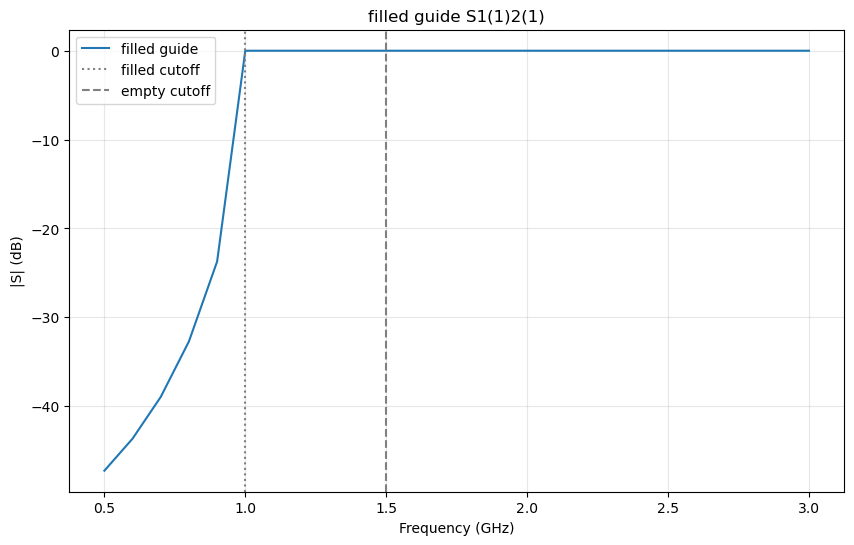

In [6]:
import matplotlib.pyplot as plt
import numpy as np

c0 = 299792458.0
fc_empty = c0 / (2 * 0.1)
fc_filled = fc_empty / np.sqrt(2.25)
print(f"cutoff empty: {fc_empty / 1e9:.3f} GHz, filled: {fc_filled / 1e9:.3f} GHz")

fom = proj.fds.fom
fig, ax = fom.plot_s(["1(1)2(1)"], label="filled guide")
ax.axvline(fc_filled / 1e9, color="grey", ls=":", label="filled cutoff")
ax.axvline(fc_empty / 1e9, color="grey", ls="--", label="empty cutoff")
ax.legend()
plt.show()

Transmission now starts at the dotted line, 1.0 GHz, instead of the dashed one.

### 2.3 Compare with the exact solution

For a uniformly filled guide the exact result is a single formula. The TE10
wave travels with $k_z = \sqrt{\varepsilon_r k_0^2 - (\pi/a)^2}$, so

$$S_{21} = e^{-j k_z L}, \qquad
  Z_{21} = \frac{-j Z_\mathrm{TE}}{\sin k_z L}, \qquad
  Z_\mathrm{TE} = \frac{\omega \mu_0}{k_z}.$$

We evaluate it on a fine grid and draw it against our 26 samples: magnitude
in dB on top, phase below, $S_{21}$ left, $Z_{21}$ right.

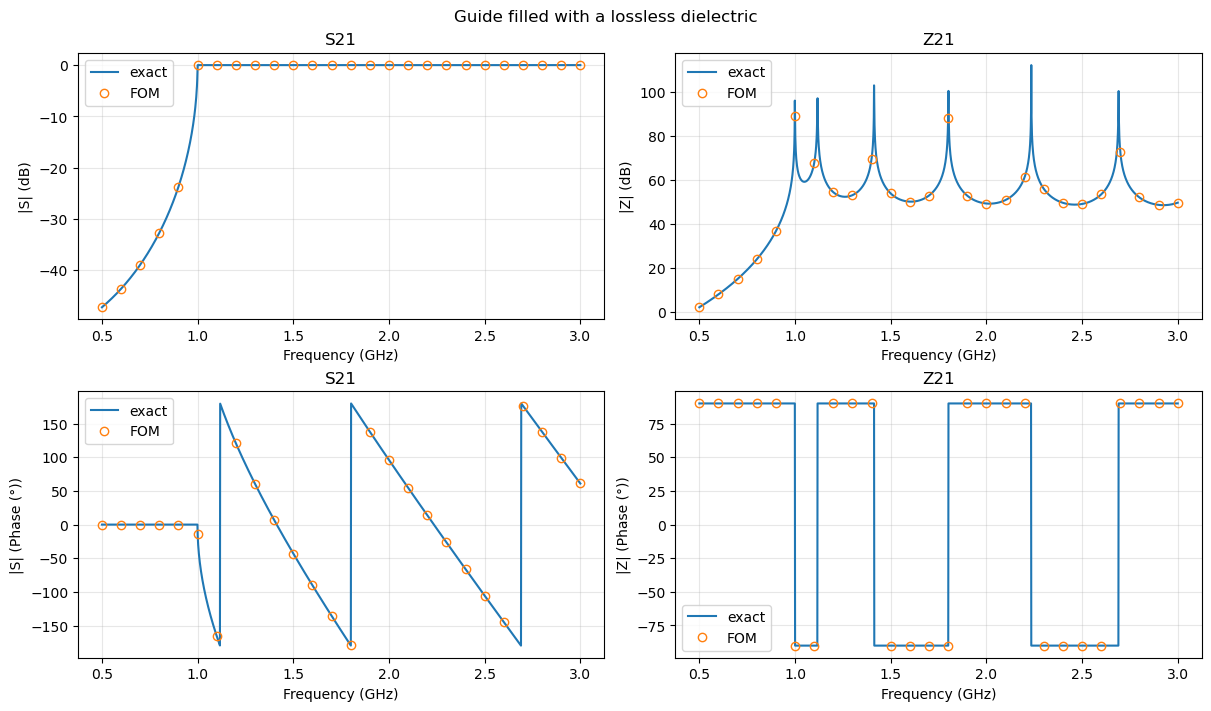

In [7]:
mu0 = 4e-7 * np.pi
eps_r, a, L = 2.25, 0.1, 0.2

f_fine = np.linspace(0.5e9, 3.0e9, 2000)
k0 = 2 * np.pi * f_fine / c0
kz = np.sqrt(eps_r * k0**2 - (np.pi / a)**2 + 0j)
kz = np.where(kz.imag > 0, -kz, kz)               # the decaying branch below cutoff
S21_exact = np.exp(-1j * kz * L)
Z21_exact = -1j * (2 * np.pi * f_fine * mu0 / kz) / np.sin(kz * L)

fig, axs = plt.subplot_mosaic([["S db", "Z db"], ["S phase", "Z phase"]],
                              figsize=(12, 7), layout="constrained")
axs["S db"].plot(f_fine / 1e9, 20 * np.log10(np.abs(S21_exact)), label="exact")
axs["S phase"].plot(f_fine / 1e9, np.degrees(np.angle(S21_exact)), label="exact")
axs["Z db"].plot(f_fine / 1e9, 20 * np.log10(np.abs(Z21_exact)), label="exact")
axs["Z phase"].plot(f_fine / 1e9, np.degrees(np.angle(Z21_exact)), label="exact")
for kind in ("db", "phase"):
    fom.plot_s(["1(1)2(1)"], plot_type=kind, ax=axs[f"S {kind}"], label="FOM",
               lw=0, marker="o", mfc="none", title="S21")
    fom.plot_z(["1(1)2(1)"], plot_type=kind, ax=axs[f"Z {kind}"], label="FOM",
               lw=0, marker="o", mfc="none", title="Z21")
fig.suptitle("Guide filled with a lossless dielectric")
plt.show()

The samples lie on the exact curves on both sides of the new cutoff. As a
number, above cutoff:

In [8]:
kz_s = np.sqrt(eps_r * (2 * np.pi * f / c0)**2 - (np.pi / a)**2 + 0j)
err = np.abs(S_lossless[:, 1, 0] - np.exp(-1j * kz_s * L))
print(f"largest |S21 - exact| above 1.1 GHz: {err[f > 1.1e9].max():.1e}")

largest |S21 - exact| above 1.1 GHz: 1.1e-03


## 3. Add loss

### 3.1 Make the dielectric lossy

Give the same material a loss tangent and run the same sweep again.

In [9]:
guide.set_materials({"*": {"eps_r": 2.25, "tan_delta": 0.005}})
res = proj.fds.solve(fmin=0.5, fmax=3.0, nsamples=26)
S_lossy = res["S"]


FDS Solve: 0.5000 - 3.0000 GHz, 26 samples


Global Coupled Solve


  
Coupled solve complete: 2 external ports in 58.22s (total iteration steps: 4490)


Saved port modes to simulations\materials_and_losses\fds\port_modes\port_modes.pkl


We did not ask for a recomputation. `solve()` compared the request with the
stored results, found that the materials had changed, and solved again.

### 3.2 Compare lossless and lossy transmission

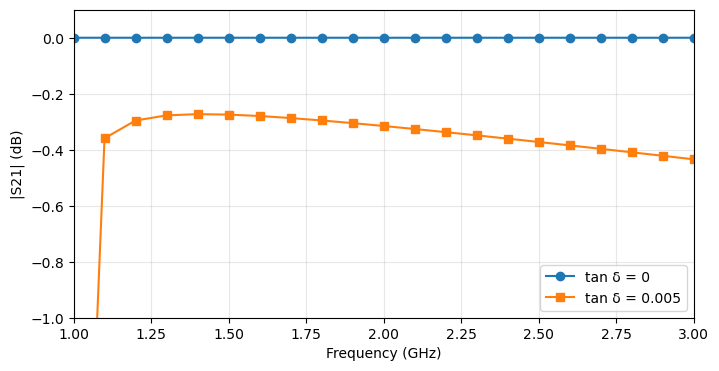

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(f / 1e9, 20 * np.log10(np.abs(S_lossless[:, 1, 0])), "o-", label="tan δ = 0")
ax.plot(f / 1e9, 20 * np.log10(np.abs(S_lossy[:, 1, 0])), "s-", label="tan δ = 0.005")
ax.set_xlim(1.0, 3.0)
ax.set_ylim(-1.0, 0.1)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("|S21| (dB)")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

Without loss $|S_{21}|$ stays at 0 dB. With loss it drops by 0.3 to 0.45 dB:
most just above the cutoff, where the wave travels slowly, and towards the top
of the band; least around 1.4 GHz.

### 3.3 Find where the power goes

Whatever is neither reflected nor transmitted is absorbed:
$1 - |S_{11}|^2 - |S_{21}|^2$. For the filled guide the exact absorbed fraction
is $1 - |e^{-j k_z L}|^2$, with $k_z$ computed from the complex permittivity
$\varepsilon_r (1 - j \tan\delta)$. We compare the two above cutoff.

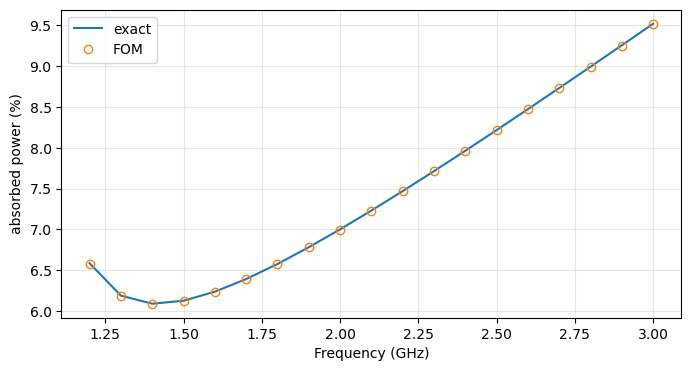

 1.2 GHz: absorbed  6.58 %  (exact  6.59 %)
 1.6 GHz: absorbed  6.23 %  (exact  6.24 %)
 2.0 GHz: absorbed  7.00 %  (exact  7.00 %)
 2.4 GHz: absorbed  7.96 %  (exact  7.96 %)
 2.8 GHz: absorbed  8.99 %  (exact  8.99 %)


In [11]:
above = f > 1.1e9
absorbed = 1 - np.abs(S_lossy[:, 0, 0])**2 - np.abs(S_lossy[:, 1, 0])**2

kz_lossy = np.sqrt(eps_r * (1 - 0.005j) * (2 * np.pi * f / c0)**2 - (np.pi / a)**2 + 0j)
kz_lossy = np.where(kz_lossy.imag > 0, -kz_lossy, kz_lossy)
absorbed_exact = 1 - np.abs(np.exp(-1j * kz_lossy * L))**2

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(f[above] / 1e9, 100 * absorbed_exact[above], label="exact")
ax.plot(f[above] / 1e9, 100 * absorbed[above], "o", mfc="none", label="FOM")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("absorbed power (%)")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

for k in np.flatnonzero(above)[::4]:
    print(f"{f[k] / 1e9:4.1f} GHz: absorbed {100 * absorbed[k]:5.2f} %  (exact {100 * absorbed_exact[k]:5.2f} %)")

The computed absorption matches the exact values to within about 0.01
percentage points: about 6.6 % at 1.2 GHz, a shallow minimum near 1.6 GHz,
and 9 % at 2.8 GHz.

## What we did

We assigned a dielectric to a waveguide, saw its cutoff drop by
$\sqrt{\varepsilon_r}$, matched $S_{21}$ and $Z_{21}$ to the exact solution,
added a loss tangent, and measured the absorbed power against the exact value.

**Next:** the [Models of several parts](../multi_part/index.md) section joins
parts with different materials.

**Related:** [How to assign materials](../../how-to/materials.md) covers
conductivity, PEC solids, and materials of imported CAD models.